Name -KAVISH PARASWAR


ROLL NO - 02   

PRN - 12311694

TYCSAI - B



Assignment 6: Build a Multiclass classifier using the CNN model. Use MNIST or any other suitable dataset.

a. Perform Data Pre-processing

b. Define Model and perform training

c. Evaluate Results using confusion matrix

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
from sklearn.metrics import confusion_matrix

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.9448 - loss: 0.1830 - val_accuracy: 0.9818 - val_loss: 0.0637
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 65ms/step - accuracy: 0.9825 - loss: 0.0561 - val_accuracy: 0.9862 - val_loss: 0.0486
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 71s 50ms/step - accuracy: 0.9886 - loss: 0.0362 - val_accuracy: 0.9883 - val_loss: 0.0421
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 53ms/step - accuracy: 0.9917 - loss: 0.0264 - val_accuracy: 0.9862 - val_loss: 0.0487
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - accuracy: 0.9936 - loss: 0.0204 - val_accuracy: 0.9894 - val_loss: 0.0365
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9909 - loss: 0.0304
Test Accuracy: 0.9908999800682068
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


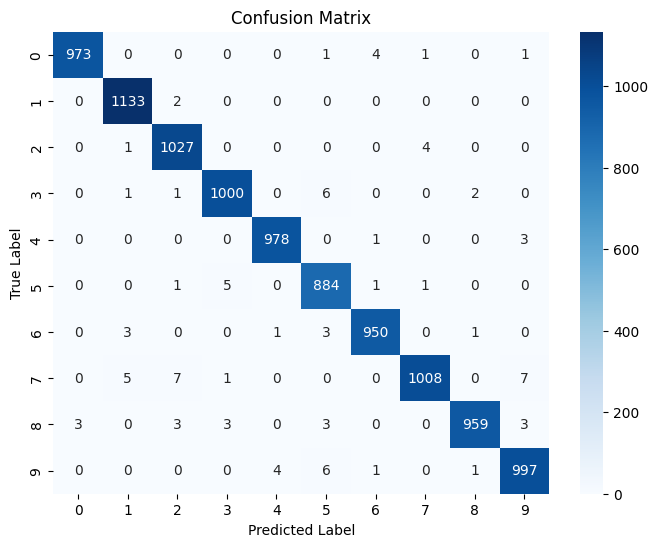

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Build CNN model
model = Sequential()

# First convolution layer
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

# Pooling layer
model.add(MaxPooling2D((2, 2)))

# Second convolution layer
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flatten layer
model.add(Flatten())

# Dense layers
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", test_accuracy)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()